# Product Recommendation Engine — Exploratory Analysis & Walkthrough

This notebook explores the dataset and demonstrates the Content-Based, Collaborative,
and Hybrid recommenders built in `src/`.


In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

products_df = pd.read_csv('../data/products.csv')
ratings_df = pd.read_csv('../data/ratings.csv')
users_df = pd.read_csv('../data/users.csv')

print(f"Products: {len(products_df)} | Users: {len(users_df)} | Ratings: {len(ratings_df)}")
products_df.head()

Products: 150 | Users: 300 | Ratings: 6000


,product_id,product_name,category,brand,description,price
0,1,Nova Portable Bluetooth Speaker,Electronics,Nova,A Portable Bluetooth Speaker designed for ever...,18891.29
1,2,Crest Ergonomic Handbag,Fashion,Crest,Top-rated Handbag offering Ergonomic performan...,757.91
2,3,Zenith Premium Shampoo,Beauty,Zenith,This Premium Shampoo from Zenith combines styl...,1544.94
3,4,Solace High-Performance Table Lamp,Home & Kitchen,Solace,Experience the best Table Lamp in the Home & K...,5890.21
4,5,Urban Lightweight Skipping Rope,Sports & Fitness,Urban,A Lightweight Skipping Rope designed for every...,657.80


## 1. Exploratory Data Analysis

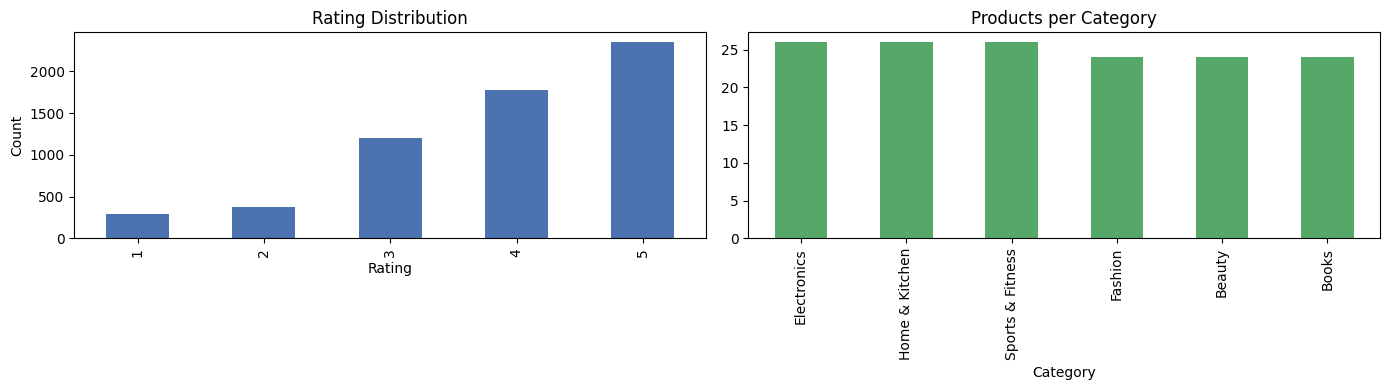

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ratings_df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

cat_counts = products_df['category'].value_counts()
cat_counts.plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Products per Category')
axes[1].set_xlabel('Category')

plt.tight_layout()
plt.show()

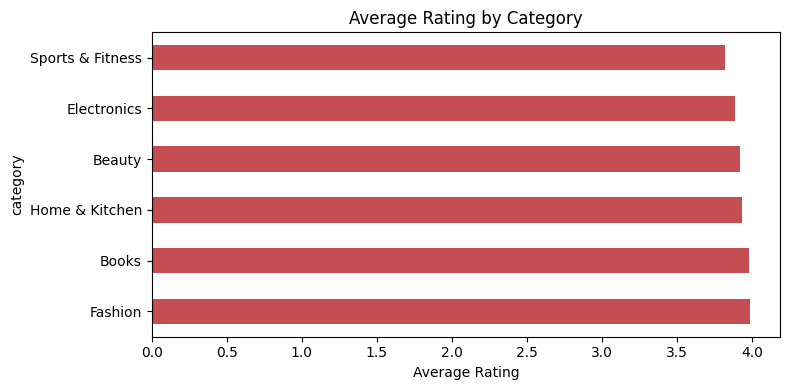

In [3]:
merged = ratings_df.merge(products_df, on='product_id')
avg_rating_by_cat = merged.groupby('category')['rating'].mean().sort_values(ascending=False)
avg_rating_by_cat.plot(kind='barh', figsize=(8,4), color='#C44E52')
plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

count    300.000000
mean      20.000000
std        3.554638
min       11.000000
25%       18.000000
50%       20.000000
75%       22.000000
max       32.000000
dtype: float64


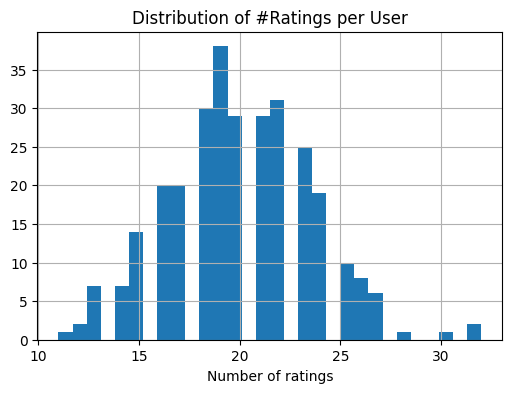

In [4]:
ratings_per_user = ratings_df.groupby('user_id').size()
print(ratings_per_user.describe())
ratings_per_user.hist(bins=30, figsize=(6,4))
plt.title('Distribution of #Ratings per User')
plt.xlabel('Number of ratings')
plt.show()

## 2. Content-Based Filtering Demo

In [5]:
from src.content_based import ContentBasedRecommender

cb = ContentBasedRecommender(products_df).fit()

sample_pid = products_df.product_id.iloc[0]
print("Query product:", products_df[products_df.product_id == sample_pid].product_name.values[0])
cb.similar_products(sample_pid, top_n=5)

Query product: Nova Portable Bluetooth Speaker


,product_id,product_name,category,brand,description,price,content,similarity_score
0,28,Vertex Smart Bluetooth Speaker,Electronics,Vertex,Upgrade your lifestyle with this Smart Bluetoo...,27052.81,Electronics Vertex Vertex Smart Bluetooth Spea...,0.593902
1,6,Nova Portable Tablet,Electronics,Nova,A Portable Tablet designed for everyday use wi...,12637.46,Electronics Nova Nova Portable Tablet A Portab...,0.520014
2,101,Nova High-Performance Dinner Set,Home & Kitchen,Nova,A High-Performance Dinner Set designed for eve...,11160.41,Home & Kitchen Nova Nova High-Performance Dinn...,0.266493
3,43,Nova Professional Dumbbell Set,Sports & Fitness,Nova,A Professional Dumbbell Set designed for every...,2510.97,Sports & Fitness Nova Nova Professional Dumbbe...,0.264156
4,133,Nova Durable Microwave Oven,Home & Kitchen,Nova,A Durable Microwave Oven designed for everyday...,1702.53,Home & Kitchen Nova Nova Durable Microwave Ove...,0.247910


## 3. Collaborative Filtering Demo (Item-based + SVD)

In [6]:
from src.collaborative import CollaborativeRecommender

cf = CollaborativeRecommender(ratings_df).fit_svd()
cf.fit_item_based()

sample_uid = ratings_df.user_id.iloc[0]
print("SVD recommendations for user", sample_uid)
for pid, score in cf.recommend_svd(sample_uid, top_n=5):
    name = products_df[products_df.product_id == pid].product_name.values[0]
    print(f"  {name}: predicted rating {score:.2f}")

SVD recommendations for user 136
  Aria Budget-Friendly Tablet: predicted rating 4.76
  Everest Wireless Camera: predicted rating 4.66
  Falcon Classic Lipstick: predicted rating 4.53
  Nova Portable Bluetooth Speaker: predicted rating 4.53
  Nimbus Classic Microwave Oven: predicted rating 4.53


## 4. Hybrid Recommender Demo

In [7]:
from src.hybrid import HybridRecommender

hybrid = HybridRecommender(products_df, ratings_df)
hybrid.recommend(sample_uid, top_n=10)

,product_id,product_name,category,brand,price,score,source
0,16,Aria Budget-Friendly Tablet,Electronics,Aria,19646.05,0.815210,hybrid (content + collaborative)
1,138,Everest Wireless Camera,Electronics,Everest,14315.67,0.773024,hybrid (content + collaborative)
2,93,Kairo Eco-Friendly Monitor,Electronics,Kairo,47540.21,0.747357,hybrid (content + collaborative)
3,1,Nova Portable Bluetooth Speaker,Electronics,Nova,18891.29,0.720167,hybrid (content + collaborative)
4,67,Pulse High-Performance Gaming Console,Electronics,Pulse,18944.39,0.665115,hybrid (content + collaborative)
5,83,Lumen Compact Smartphone,Electronics,Lumen,23723.33,0.643400,hybrid (content + collaborative)
6,6,Nova Portable Tablet,Electronics,Nova,12637.46,0.609103,hybrid (content + collaborative)
7,94,Zenith Ergonomic Gaming Console,Electronics,Zenith,23248.99,0.585552,hybrid (content + collaborative)
8,27,Vertex High-Performance Air Fryer,Home & Kitchen,Vertex,6319.22,0.578327,hybrid (content + collaborative)
9,97,Vertex Lightweight Table Lamp,Home & Kitchen,Vertex,2445.34,0.499029,hybrid (content + collaborative)


## 5. Model Evaluation

In [8]:
from src.evaluate import evaluate_svd_rmse, evaluate_hybrid

rmse_result = evaluate_svd_rmse(ratings_df)
print("SVD RMSE:", rmse_result)

rank_result = evaluate_hybrid(products_df, ratings_df, k=10)
print("Hybrid Precision@10 / Recall@10:", rank_result)

SVD RMSE: {'rmse': np.float64(1.1376152025224462), 'n_test_points_evaluated': 1200, 'n_test_points_total': 1200}


Hybrid Precision@10 / Recall@10: {'precision_at_k': np.float64(0.09722222222222222), 'recall_at_k': np.float64(0.3346395502645503), 'k': 10, 'evaluated_users': 288}
